# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
print(os.getcwd())

d:\E-Commerce Return Cost & Customer Dissatisfaction Analysis\notebook


# ==========================================
# 2. DATA LOADING
# ==========================================

In [15]:
import os

print(os.listdir(".."))

['.git', 'Data', 'notebook', 'PowerBI', 'README.md', 'SQL', 'venv', 'Visuals']


In [16]:
df = pd.read_csv("../Data/Return_Data.csv")
df.head()

,Order_ID,Product_ID,User_ID,Order_Date,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,...,Return_Status,Return_Reason,Days_to_Return,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
0,ORD00000,PROD0169,USER0195,2022-01-14,Clothing,1720.71,2,30.46,Next-Day,Wallet,...,Not Returned,No Return,0,2393.163468,0,2393.163468,2.0,0.4,2.0,0.4
1,ORD00001,PROD0318,USER1469,2022-01-03,Toys,744.06,5,29.62,Next-Day,Wallet,...,Returned,Size Issue,12,2618.347140,200,2418.347140,2.0,1.0,0.0,0.0
2,ORD00002,PROD0427,USER1812,2025-03-16,Clothing,983.68,5,47.80,Express,Wallet,...,Not Returned,No Return,0,2567.404800,0,2567.404800,1.5,1.0,1.5,1.0
3,ORD00003,PROD0323,USER1274,2024-11-06,Books,1855.65,2,2.90,Express,COD,...,Not Returned,No Return,0,3603.672300,0,3603.672300,1.5,0.4,1.5,0.4
4,ORD00004,PROD0325,USER0551,2023-06-07,Home Appliances,1770.97,5,44.42,Express,COD,...,Returned,Size Issue,11,4921.525630,200,4721.525630,1.5,1.0,0.0,0.0


# ==========================================
# 3. DATA AUDIT
# ==========================================

In [17]:
#Dataset Structure Analysis
df.shape

(5000, 23)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          5000 non-null   str    
 1   Product_ID        5000 non-null   str    
 2   User_ID           5000 non-null   str    
 3   Order_Date        5000 non-null   str    
 4   Product_Category  5000 non-null   str    
 5   Product_Price     5000 non-null   float64
 6   Order_Quantity    5000 non-null   int64  
 7   Discount_Applied  5000 non-null   float64
 8   Shipping_Method   5000 non-null   str    
 9   Payment_Method    5000 non-null   str    
 10  User_Age          5000 non-null   int64  
 11  User_Gender       5000 non-null   str    
 12  User_Location     5000 non-null   str    
 13  Return_Status     5000 non-null   str    
 14  Return_Reason     5000 non-null   str    
 15  Days_to_Return    5000 non-null   int64  
 16  Order_Value       5000 non-null   float64
 17  Return

In [19]:
df.head()

,Order_ID,Product_ID,User_ID,Order_Date,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,...,Return_Status,Return_Reason,Days_to_Return,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
0,ORD00000,PROD0169,USER0195,2022-01-14,Clothing,1720.71,2,30.46,Next-Day,Wallet,...,Not Returned,No Return,0,2393.163468,0,2393.163468,2.0,0.4,2.0,0.4
1,ORD00001,PROD0318,USER1469,2022-01-03,Toys,744.06,5,29.62,Next-Day,Wallet,...,Returned,Size Issue,12,2618.347140,200,2418.347140,2.0,1.0,0.0,0.0
2,ORD00002,PROD0427,USER1812,2025-03-16,Clothing,983.68,5,47.80,Express,Wallet,...,Not Returned,No Return,0,2567.404800,0,2567.404800,1.5,1.0,1.5,1.0
3,ORD00003,PROD0323,USER1274,2024-11-06,Books,1855.65,2,2.90,Express,COD,...,Not Returned,No Return,0,3603.672300,0,3603.672300,1.5,0.4,1.5,0.4
4,ORD00004,PROD0325,USER0551,2023-06-07,Home Appliances,1770.97,5,44.42,Express,COD,...,Returned,Size Issue,11,4921.525630,200,4721.525630,1.5,1.0,0.0,0.0


In [20]:
df.isnull().sum()

Order_ID            0
Product_ID          0
User_ID             0
Order_Date          0
Product_Category    0
Product_Price       0
Order_Quantity      0
Discount_Applied    0
Shipping_Method     0
Payment_Method      0
User_Age            0
User_Gender         0
User_Location       0
Return_Status       0
Return_Reason       0
Days_to_Return      0
Order_Value         0
Return_Cost         0
Profit_Loss         0
CO2_Emissions       0
Packaging_Waste     0
CO2_Saved           0
Waste_Avoided       0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.describe()

,Product_Price,Order_Quantity,Discount_Applied,User_Age,Days_to_Return,Order_Value,Return_Cost,Profit_Loss,CO2_Emissions,Packaging_Waste,CO2_Saved,Waste_Avoided
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,1054.294740,2.997600,25.011476,41.551800,9.204200,2366.996469,58.000000,2308.996469,1.500100,0.599520,1.066600,0.42668
std,548.560406,1.400709,14.430681,13.890195,16.753156,1834.851991,90.761487,1838.461511,0.410346,0.280142,0.764448,0.36150
min,100.090000,1.000000,0.000000,18.000000,0.000000,52.165727,0.000000,-147.834273,1.000000,0.200000,0.000000,0.00000
25%,580.937500,2.000000,12.827500,30.000000,0.000000,928.078449,0.000000,863.905130,1.000000,0.400000,0.000000,0.00000
50%,1044.850000,3.000000,25.020000,42.000000,0.000000,1864.584054,0.000000,1808.077845,1.500000,0.600000,1.000000,0.40000
75%,1530.835000,4.000000,37.380000,54.000000,12.000000,3382.309799,200.000000,3345.675860,2.000000,0.800000,1.500000,0.80000
max,1999.800000,5.000000,50.000000,65.000000,60.000000,9827.017200,200.000000,9827.017200,2.000000,1.000000,2.000000,1.00000


# ==========================================
# 4. DATA CLEANING
# ==========================================

In [23]:
df.nunique()

Order_ID            5000
Product_ID           500
User_ID             1858
Order_Date          1309
Product_Category       5
Product_Price       4924
Order_Quantity         5
Discount_Applied    3177
Shipping_Method        3
Payment_Method         4
User_Age              48
User_Gender            2
User_Location        100
Return_Status          2
Return_Reason          5
Days_to_Return        57
Order_Value         5000
Return_Cost            2
Profit_Loss         5000
CO2_Emissions          3
Packaging_Waste        5
CO2_Saved              4
Waste_Avoided          6
dtype: int64

In [24]:
df['Shipping_Method'].unique()

<StringArray>
['Next-Day', 'Express', 'Standard']
Length: 3, dtype: str

In [25]:
df['Payment_Method'].unique()

<StringArray>
['Wallet', 'COD', 'Credit Card', 'Debit Card']
Length: 4, dtype: str

In [26]:
df['Return_Status'].unique()

<StringArray>
['Not Returned', 'Returned']
Length: 2, dtype: str

In [27]:
df['Return_Reason'].unique()

<StringArray>
['No Return', 'Size Issue', 'Changed Mind', 'Wrong Item', 'Defective']
Length: 5, dtype: str

In [28]:
df['Return_Cost'].unique()

array([  0, 200])

In [29]:
df['CO2_Emissions'].unique()

array([2. , 1.5, 1. ])

In [30]:
df['CO2_Saved'].unique()

array([2. , 0. , 1.5, 1. ])

In [31]:
df['Order_Quantity'].unique()

array([2, 5, 1, 4, 3])

In [32]:
df['Product_Category'].unique()

<StringArray>
['Clothing', 'Toys', 'Books', 'Home Appliances', 'Electronics']
Length: 5, dtype: str

- Dataset contains customer, product, financial, return and sustainability information.
- Repeat customers exist (1858 customers, 5000 orders).
- Product-level analysis is possible.
- Category-level analysis is possible.
- Geographic analysis is possible.
- Sustainability analysis is possible.

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          5000 non-null   str    
 1   Product_ID        5000 non-null   str    
 2   User_ID           5000 non-null   str    
 3   Order_Date        5000 non-null   str    
 4   Product_Category  5000 non-null   str    
 5   Product_Price     5000 non-null   float64
 6   Order_Quantity    5000 non-null   int64  
 7   Discount_Applied  5000 non-null   float64
 8   Shipping_Method   5000 non-null   str    
 9   Payment_Method    5000 non-null   str    
 10  User_Age          5000 non-null   int64  
 11  User_Gender       5000 non-null   str    
 12  User_Location     5000 non-null   str    
 13  Return_Status     5000 non-null   str    
 14  Return_Reason     5000 non-null   str    
 15  Days_to_Return    5000 non-null   int64  
 16  Order_Value       5000 non-null   float64
 17  Return

In [34]:
df['Return_Status'].value_counts()

Return_Status
Not Returned    3550
Returned        1450
Name: count, dtype: int64

In [35]:
df['Return_Status'].value_counts(normalize=True)*100

Return_Status
Not Returned    71.0
Returned        29.0
Name: proportion, dtype: float64

In [36]:
df['Return_Reason'].value_counts()

Return_Reason
No Return       3550
Defective        382
Changed Mind     379
Wrong Item       348
Size Issue       341
Name: count, dtype: int64

In [37]:
# return reason for returned products
df[df['Return_Status']=='Returned']['Return_Reason'].value_counts()

Return_Reason
Defective       382
Changed Mind    379
Wrong Item      348
Size Issue      341
Name: count, dtype: int64

product analysis

In [38]:
# Category-wise return comparison
pd.crosstab(
    df['Product_Category'],
    df['Return_Status']
)

Return_Status,Not Returned,Returned
Product_Category,,
Books,590,172
Clothing,1105,661
Electronics,930,314
Home Appliances,354,122
Toys,571,181


In [39]:
# Category-wise sales value
df.groupby('Product_Category')['Order_Value'].sum()

Product_Category
Books              1.750236e+06
Clothing           4.170020e+06
Electronics        2.908236e+06
Home Appliances    1.151587e+06
Toys               1.854903e+06
Name: Order_Value, dtype: float64

In [40]:
# Shipping Analysis
pd.crosstab(
    df['Shipping_Method'],
    df['Return_Status']
)

Return_Status,Not Returned,Returned
Shipping_Method,,
Express,1158,475
Next-Day,1204,480
Standard,1188,495


In [41]:
# Shipping-wise return cost
df.groupby('Shipping_Method')['Return_Cost'].sum()

Shipping_Method
Express     95000
Next-Day    96000
Standard    99000
Name: Return_Cost, dtype: int64

In [42]:
# Payment Analysis
# Payment method aur return behavior comparison
pd.crosstab(
    df['Payment_Method'],
    df['Return_Status']
)

Return_Status,Not Returned,Returned
Payment_Method,,
COD,843,370
Credit Card,852,383
Debit Card,926,351
Wallet,929,346


In [43]:
# Customer Demographics
# Gender-wise return behavior comparison
df.groupby('User_Gender')['Return_Status'].value_counts()

User_Gender  Return_Status
Female       Not Returned     1798
             Returned          778
Male         Not Returned     1752
             Returned          672
Name: count, dtype: int64

In [44]:
# Age-wise return behavior comparison
df.groupby('User_Age')['Return_Status'].value_counts()

User_Age  Return_Status
18        Not Returned     82
          Returned         24
19        Not Returned     88
          Returned         36
20        Not Returned     72
                           ..
63        Returned         32
64        Not Returned     80
          Returned         33
65        Not Returned     65
          Returned         29
Name: count, Length: 96, dtype: int64

In [45]:
# Discount Analysis
# Discount applied aur return behavior comparison
df.groupby('Discount_Applied')['Return_Status'].value_counts()

Discount_Applied  Return_Status
0.00              Not Returned     1
0.01              Not Returned     1
0.05              Returned         1
0.06              Not Returned     3
0.07              Returned         1
                                  ..
49.95             Not Returned     2
49.96             Not Returned     1
49.97             Not Returned     1
                  Returned         1
50.00             Not Returned     1
Name: count, Length: 3817, dtype: int64

Financial Impact

In [46]:
# Profit/Loss by return status
df.groupby('Return_Status')['Profit_Loss'].sum()

Return_Status
Not Returned    8.465591e+06
Returned        3.079392e+06
Name: Profit_Loss, dtype: float64

In [47]:
# Total return cost
df['Return_Cost'].sum()

np.int64(290000)

Sustainablity Analysis

In [48]:
# Environmental Impact on return status
df.groupby('Return_Status')['CO2_Emissions'].sum()

Return_Status
Not Returned    5333.0
Returned        2167.5
Name: CO2_Emissions, dtype: float64

In [49]:
# Packaging waste by return status
df.groupby('Return_Status')['Packaging_Waste'].sum()

Return_Status
Not Returned    2133.4
Returned         864.2
Name: Packaging_Waste, dtype: float64

# ==========================================
# 5. FEATURE ENGINEERING
# ==========================================


In [50]:
# creating age groups
bins = [18, 25 , 35, 45, 55, 65]

labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
df['Age_Group'] = pd.cut(
    df['User_Age'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True)

In [51]:
df['Age_Group'].value_counts()

Age_Group
56-65    1050
36-45    1048
46-55    1032
26-35    1025
18-25     845
Name: count, dtype: int64

In [52]:
# Creating discount buckets
bins = [0, 10, 20, 30, 40, 50]
labels = ['0-10%', '11-20%', '21-30%', '31-40%', '41-50%']
df['Discount_Bucket'] = pd.cut(
    df['Discount_Applied'],
    bins=bins,
    labels = labels,
    include_lowest=True
)

In [53]:
df['Discount_Bucket'].value_counts()

Discount_Bucket
21-30%    1054
41-50%    1021
11-20%    1005
0-10%      977
31-40%     943
Name: count, dtype: int64

In [54]:
df['Return_Flag'] = df['Return_Status'].map({
    'Returned': 1,
    'Not Returned': 0
})

In [55]:
df['Return_Flag'].value_counts()

Return_Flag
0    3550
1    1450
Name: count, dtype: int64

In [56]:
df['Return_Flag'].mean()

np.float64(0.29)

In [57]:
# Return rates by age group
df.groupby('Age_Group')['Return_Flag'].mean()

Age_Group
18-25    0.291124
26-35    0.294634
36-45    0.296756
46-55    0.275194
56-65    0.292381
Name: Return_Flag, dtype: float64

In [58]:
# Return rates by discount bucket
df.groupby('Product_Category')['Return_Flag'].mean()

Product_Category
Books              0.225722
Clothing           0.374292
Electronics        0.252412
Home Appliances    0.256303
Toys               0.240691
Name: Return_Flag, dtype: float64

In [59]:
# Return rates by product category
df.groupby('Discount_Bucket')['Return_Flag'].mean()

Discount_Bucket
0-10%     0.240532
11-20%    0.268657
21-30%    0.259013
31-40%    0.352068
41-50%    0.333007
Name: Return_Flag, dtype: float64

In [60]:
df['Order_Date'].dtype

<StringDtype(storage='python', na_value=nan)>

In [61]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

In [62]:
df['Order_Date'].dtype

dtype('<M8[us]')

In [63]:
# Extracting month name from Order_Date
df['Order_Month'] = df['Order_Date'].dt.month_name()

In [64]:
df['Order_Month'].value_counts()

Order_Month
May          481
January      467
August       464
July         461
March        456
June         443
April        438
February     435
December     381
September    331
October      325
November     318
Name: count, dtype: int64

In [65]:
df['Order_Year'] = df['Order_Date'].dt.year

In [66]:
df['Order_Year'].value_counts().sort_index()

Order_Year
2022    1367
2023    1319
2024    1368
2025     946
Name: count, dtype: int64

# ==========================================
# 6. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

Overall return rate

In [67]:
df['Return_Flag'].mean()*100

np.float64(28.999999999999996)

In [68]:
#Category-wise return rate - sorted by return rate
category_returns = (
    df.groupby('Product_Category')['Return_Flag']
      .mean()
      .sort_values(ascending=False)*100
)

category_returns

Product_Category
Clothing           37.429219
Home Appliances    25.630252
Electronics        25.241158
Toys               24.069149
Books              22.572178
Name: Return_Flag, dtype: float64

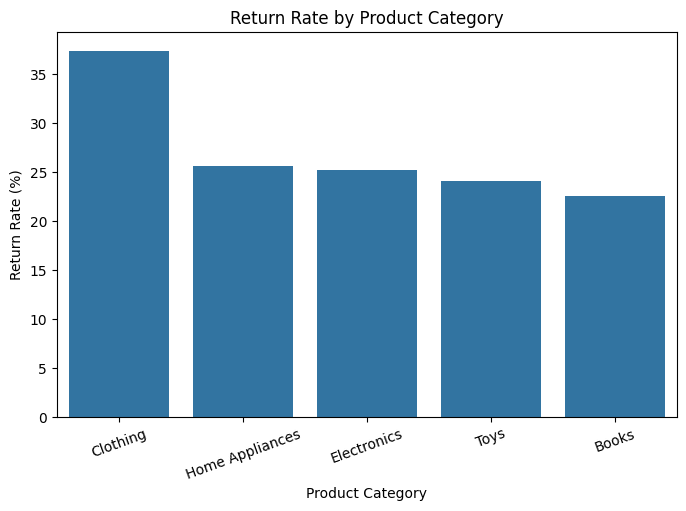

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_returns.index,
    y=category_returns.values
)

plt.title('Return Rate by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Return Rate (%)')

plt.xticks(rotation=20)

plt.show()

In [70]:
# Return Rate by Discount Bucket
discount_returns = (
    df.groupby('Discount_Bucket')['Return_Flag']
      .mean()
      .sort_values(ascending=False)*100
)

discount_returns

Discount_Bucket
31-40%    35.206787
41-50%    33.300686
11-20%    26.865672
21-30%    25.901328
0-10%     24.053224
Name: Return_Flag, dtype: float64

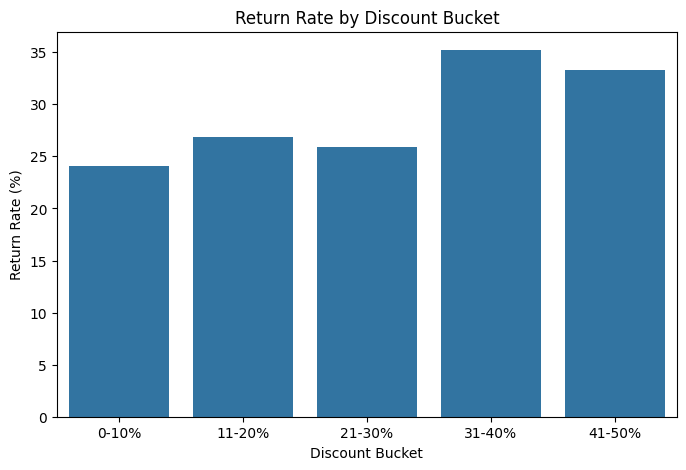

In [71]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=discount_returns.index,
    y=discount_returns.values
)

plt.title('Return Rate by Discount Bucket')
plt.xlabel('Discount Bucket')
plt.ylabel('Return Rate (%)')

plt.show()

In [72]:
age_returns = (
    df.groupby('Age_Group')['Return_Flag']
      .mean()
      .sort_values(ascending=False)*100
)
age_returns

Age_Group
36-45    29.675573
26-35    29.463415
56-65    29.238095
18-25    29.112426
46-55    27.519380
Name: Return_Flag, dtype: float64

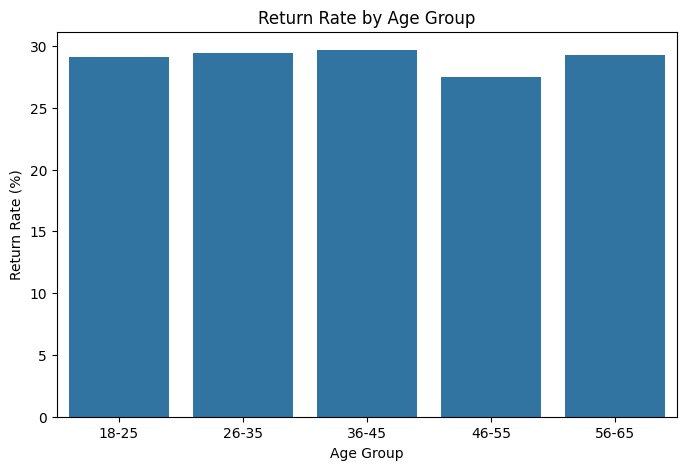

In [73]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=age_returns.index,
    y=age_returns.values
)
plt.title('Return Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Return Rate (%)')
plt.show()

In [74]:
payment_returns = (
    df.groupby('Payment_Method')['Return_Flag']
      .mean()
      .sort_values(ascending=False)*100
)

payment_returns

Payment_Method
Credit Card    31.012146
COD            30.502885
Debit Card     27.486296
Wallet         27.137255
Name: Return_Flag, dtype: float64

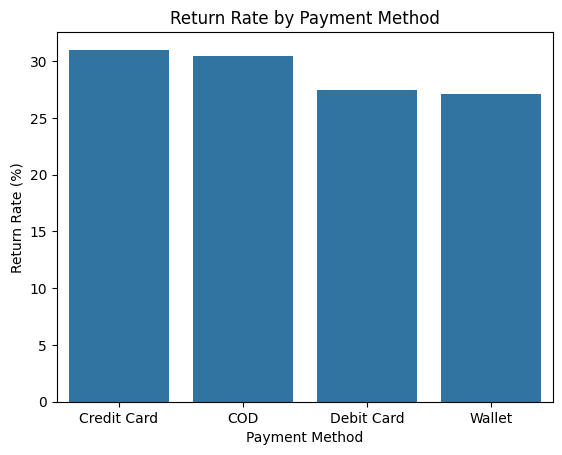

In [75]:
plt.Figure(figsize=(8,5))

sns.barplot(
    x=payment_returns.index,
    y=payment_returns.values 
  
)

plt.title('Return Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Return Rate (%)')

plt.show()

In [76]:
shipping_returns = (
    df.groupby('Shipping_Method')['Return_Flag']
      .mean()
      .sort_values(ascending=False)*100
)

shipping_returns

Shipping_Method
Standard    29.411765
Express     29.087569
Next-Day    28.503563
Name: Return_Flag, dtype: float64

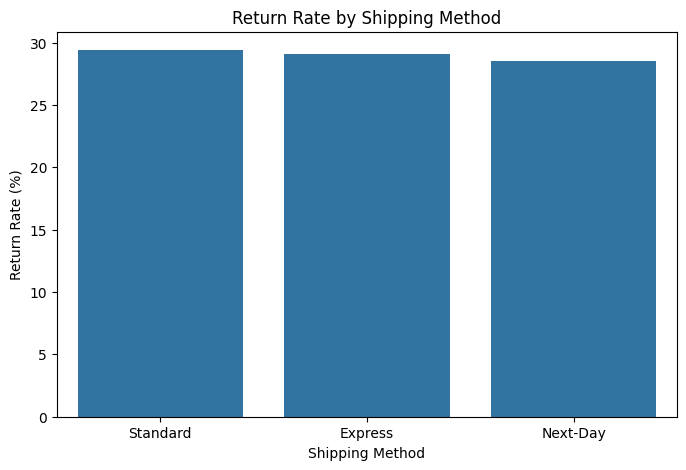

In [77]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_returns.index,
    y=shipping_returns.values
)

plt.title('Return Rate by Shipping Method')
plt.xlabel('Shipping Method')
plt.ylabel('Return Rate (%)')

plt.show()

In [78]:
returned_df = df[df['Return_Status'] == 'Returned']

reason_counts = returned_df['Return_Reason'].value_counts()

reason_counts

Return_Reason
Defective       382
Changed Mind    379
Wrong Item      348
Size Issue      341
Name: count, dtype: int64

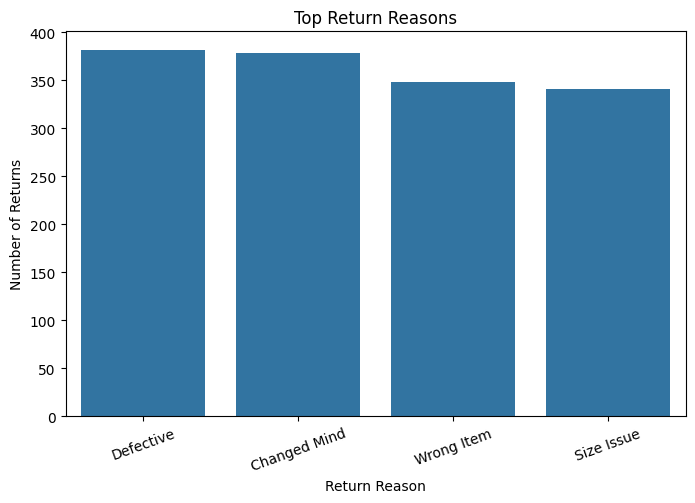

In [79]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=reason_counts.index,
    y=reason_counts.values
)

plt.title('Top Return Reasons')
plt.xlabel('Return Reason')
plt.ylabel('Number of Returns')

plt.xticks(rotation=20)

plt.show()

Clothing has highest return rate (~37%)

Discounts above 30% show significantly higher return rates

Defective products are the #1 return reason

Shipping method has negligible impact

Age group has negligible impact

In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          5000 non-null   str           
 1   Product_ID        5000 non-null   str           
 2   User_ID           5000 non-null   str           
 3   Order_Date        5000 non-null   datetime64[us]
 4   Product_Category  5000 non-null   str           
 5   Product_Price     5000 non-null   float64       
 6   Order_Quantity    5000 non-null   int64         
 7   Discount_Applied  5000 non-null   float64       
 8   Shipping_Method   5000 non-null   str           
 9   Payment_Method    5000 non-null   str           
 10  User_Age          5000 non-null   int64         
 11  User_Gender       5000 non-null   str           
 12  User_Location     5000 non-null   str           
 13  Return_Status     5000 non-null   str           
 14  Return_Reason     5000 non-null   s

In [81]:
pd.crosstab(
    df['Product_Category'],
    df['Return_Reason']
)

Return_Reason,Changed Mind,Defective,No Return,Size Issue,Wrong Item
Product_Category,,,,,
Books,47,41,590,44,40
Clothing,166,179,1105,151,165
Electronics,93,77,930,74,70
Home Appliances,31,33,354,30,28
Toys,42,52,571,42,45


In [82]:
df.groupby('Product_Category')['Return_Cost'].sum().sort_values(ascending=False)

Product_Category
Clothing           132200
Electronics         62800
Toys                36200
Books               34400
Home Appliances     24400
Name: Return_Cost, dtype: int64

In [83]:
df.groupby('Product_Category')['Profit_Loss'].sum().sort_values(ascending=False)

Product_Category
Clothing           4.037820e+06
Electronics        2.845436e+06
Toys               1.818703e+06
Books              1.715836e+06
Home Appliances    1.127187e+06
Name: Profit_Loss, dtype: float64

In [84]:
df.groupby('Discount_Bucket')['Profit_Loss'].sum().sort_values(ascending=False)

Discount_Bucket
0-10%     2.971287e+06
11-20%    2.553241e+06
21-30%    2.434078e+06
31-40%    1.831716e+06
41-50%    1.754660e+06
Name: Profit_Loss, dtype: float64

In [85]:
df.groupby('Product_Category')['Return_Flag'].agg(
    ['count','sum']
)

,count,sum
Product_Category,,
Books,762,172
Clothing,1766,661
Electronics,1244,314
Home Appliances,476,122
Toys,752,181


In [86]:
month_returns = (
    df.groupby('Order_Month')['Return_Flag']
      .mean()
      .sort_values(ascending=False)*100
)

month_returns

Order_Month
July         32.754881
October      32.307692
February     31.494253
April        31.278539
September    29.607251
December     28.608924
May          28.482328
March        28.070175
August       27.586207
November     27.358491
January      25.695931
June         25.507901
Name: Return_Flag, dtype: float64

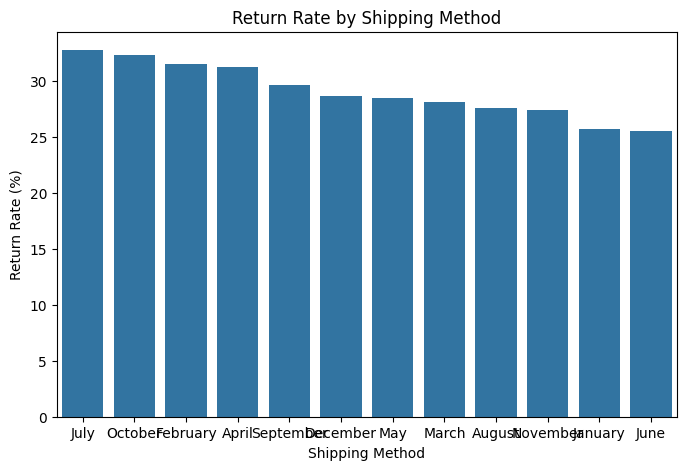

In [87]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=month_returns.index,
    y=month_returns.values
)

plt.title('Return Rate by Shipping Method')
plt.xlabel('Shipping Method')
plt.ylabel('Return Rate (%)')
plt.show()

In [88]:
year_returns = (
    df.groupby('Order_Year')['Return_Flag']
      .mean()*100
)

year_returns

Order_Year
2022    26.481346
2023    29.643669
2024    31.359649
2025    28.329810
Name: Return_Flag, dtype: float64

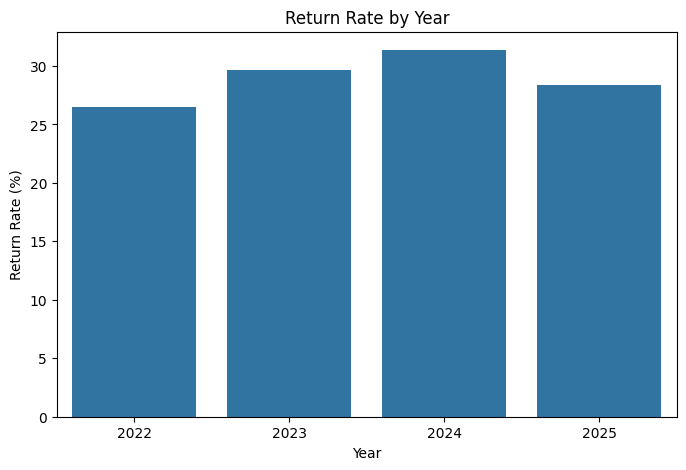

In [89]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=year_returns.index,
    y=year_returns.values
)

plt.title('Return Rate by Year')
plt.xlabel('Year')
plt.ylabel('Return Rate (%)')

plt.show()

Order Quantity

In [90]:
quantity_returns = (
    df.groupby('Order_Quantity')['Return_Flag']
      .mean()*100
)

quantity_returns

Order_Quantity
1    28.274428
2    29.811321
3    30.824742
4    28.256705
5    27.800830
Name: Return_Flag, dtype: float64

In [91]:
df['Price_Bucket'] = pd.qcut(
    df['Product_Price'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Premium']
)

In [92]:
df['Price_Bucket'].value_counts()

Price_Bucket
Low        1250
Medium     1250
High       1250
Premium    1250
Name: count, dtype: int64

In [93]:
price_returns = (
    df.groupby('Price_Bucket')['Return_Flag']
      .mean()*100
)

price_returns

Price_Bucket
Low        29.44
Medium     26.88
High       30.40
Premium    29.28
Name: Return_Flag, dtype: float64

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          5000 non-null   str           
 1   Product_ID        5000 non-null   str           
 2   User_ID           5000 non-null   str           
 3   Order_Date        5000 non-null   datetime64[us]
 4   Product_Category  5000 non-null   str           
 5   Product_Price     5000 non-null   float64       
 6   Order_Quantity    5000 non-null   int64         
 7   Discount_Applied  5000 non-null   float64       
 8   Shipping_Method   5000 non-null   str           
 9   Payment_Method    5000 non-null   str           
 10  User_Age          5000 non-null   int64         
 11  User_Gender       5000 non-null   str           
 12  User_Location     5000 non-null   str           
 13  Return_Status     5000 non-null   str           
 14  Return_Reason     5000 non-null   s

In [95]:
Gender_Return=df.groupby('User_Gender')['Return_Flag'].mean()*100

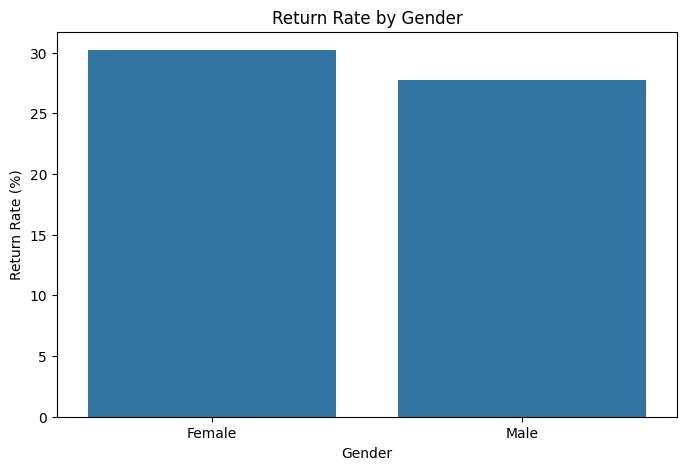

In [96]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=Gender_Return.index,
    y=Gender_Return.values
)

plt.title('Return Rate by Gender')
plt.xlabel('Gender')    
plt.ylabel('Return Rate (%)')   

plt.show()

In [97]:
location_returns = (
    df.groupby('User_Location')['Return_Flag']
      .mean()*100
)

location_returns.sort_values(ascending=False).head(10)

User_Location
City44    50.000000
City85    43.902439
City77    43.181818
City55    42.000000
City58    42.000000
City5     41.666667
City56    40.000000
City90    39.622642
City20    38.709677
City62    38.461538
Name: Return_Flag, dtype: float64

In [98]:
df.groupby('User_Location')['Return_Flag'].agg(
    ['count','sum','mean']
).sort_values('mean', ascending=False).head(10)

,count,sum,mean
User_Location,,,
City44,38,19,0.500000
City85,41,18,0.439024
City77,44,19,0.431818
City55,50,21,0.420000
City58,50,21,0.420000
City5,48,20,0.416667
City56,30,12,0.400000
City90,53,21,0.396226
City20,62,24,0.387097


Sustainability Analysis

Which product categories contribute the highest environmental impact?

In [99]:
df.groupby('Product_Category')['CO2_Emissions'].sum().sort_values(ascending=False)

Product_Category
Clothing           2631.5
Electronics        1858.0
Books              1159.5
Toys               1130.0
Home Appliances     721.5
Name: CO2_Emissions, dtype: float64

In [100]:
df.groupby('Product_Category')['Packaging_Waste'].sum().sort_values(ascending=False)

Product_Category
Clothing           1043.8
Electronics         753.6
Toys                461.2
Books               449.4
Home Appliances     289.6
Name: Packaging_Waste, dtype: float64

In [101]:
df.groupby('Discount_Bucket')['Return_Cost'].sum().sort_values(ascending=False)

Discount_Bucket
41-50%    68000
31-40%    66400
21-30%    54600
11-20%    54000
0-10%     47000
Name: Return_Cost, dtype: int64